In [11]:
""" This code is just to show that the gradient based VR algorithms explode before prox based ones.  At the moment the experiment is still
on going to make different tests.
"""

import numpy as np
import matplotlib.pyplot as plt
import time
# from scipy.special import rel_entr

def kl_row_loss(z, b_i):
    z = max(z, 1e-15)
    if b_i <= 0:
        return z
    return b_i * np.log(b_i / z) - b_i + z


def kl_divergence_poisson(A, b, x):
    Ax = A @ x
    if np.any(Ax <= 0):
        return np.inf
    return np.mean([kl_row_loss(Ax[i], b[i]) for i in range(len(b))])


def row_gradient_diagonal(a_diag, b, x, i, eps=1e-15):
    """
    Gradient of the i-th component loss in the diagonal case A = diag(a_diag).

    For diagonal A, the row loss depends only on x_i and
        grad f_i(x) = (a_i - b_i / x_i) e_i.

    Parameters
    ----------
    a_diag : ndarray, shape (d,)
        Diagonal of A.
    b : ndarray, shape (d,)
        Data vector.
    x : ndarray, shape (d,)
        Current iterate.
    i : int
        Sampled coordinate / row index.
    eps : float
        Numerical safeguard for division.

    Returns
    -------
    ndarray, shape (d,)
        Sparse gradient vector with only coordinate i potentially nonzero.
    """
    grad = np.zeros_like(x)
    grad[i] = a_diag[i] - b[i] / max(x[i], eps)
    return grad

def full_gradient_diagonal(a_diag, b, x):
    """
    Full gradient for the diagonal Poisson/KL model.

    Parameters
    ----------
    a_diag : ndarray, shape (d,)
        Diagonal entries of A.
    b : ndarray, shape (d,)
        Data vector.
    x : ndarray, shape (d,)
        Current iterate.

    Returns
    -------
    grad : ndarray, shape (d,)
        Full gradient (average over rows).
    """
    d = len(a_diag)
    grad = np.zeros(d)

    for i in range(d):
        grad += row_gradient_diagonal(a_diag, b, x, i)

    return grad / d

def bregman_prox_diagonal(x, a_diag, b, correction, step_size, i, eps=1e-20):
    """
    Closed-form implicit Bregman update for the diagonal case.

    This solves the diagonal subproblem associated with h(x) = -sum_j log x_j.
    The vector `correction` plays the role of the variance-reduction term
    (stored gradient minus running average).

    Parameters
    ----------
    x : ndarray, shape (d,)
        Current positive iterate.
    a_diag : ndarray, shape (d,)
        Diagonal entries of A.
    b : ndarray, shape (d,)
        Data vector.
    correction : ndarray, shape (d,)
        Variance-reduction correction term.
    step_size : float
        Step size.
    i : int
        Active coordinate index.
    eps : float
        Numerical safeguard.

    Returns
    -------
    ndarray, shape (d,)
        Updated iterate.
    """
    x = np.asarray(x, dtype=float)
    a_diag = np.asarray(a_diag, dtype=float)
    b = np.asarray(b, dtype=float)
    correction = np.asarray(correction, dtype=float)

    # First apply the correction to all coordinates.
    denom = 1.0 / np.maximum(x, eps) - step_size * correction
    if np.any(denom <= eps):
        raise ValueError("Encountered a non-positive denominator in the Bregman update.")
    x_new = 1.0 / denom

    # Then update the active coordinate using the closed-form diagonal formula.
    denom_i = 1.0 / max(x[i], eps) - step_size * (correction[i] - a_diag[i])
    if denom_i <= eps:
        raise ValueError("Encountered a non-positive active-coordinate denominator.")
    x_new[i] = (1.0 + step_size * b[i]) / denom_i

    if np.any(x_new <= 0):
        raise ValueError("Non-positive iterate encountered. Try a smaller step size.")
    return x_new


def sapa_bregman_diagonal(
    A,
    b,
    step_size,
    x0,
    max_iter,
    seed=None,
    use_vr=True,
    diminishing_step=False,
):
    """
    Implicit Bregman-SAPA / Bregman-SVRG-like method for diagonal A.

    Parameters
    ----------
    A : ndarray, shape (d, d)
        Diagonal forward operator.
    b : ndarray, shape (d,)
        Data vector.
    step_size : float
        Base step size.
    x0 : ndarray, shape (d,)
        Initial positive iterate.
    max_iter : int
        Number of stochastic iterations.
    seed : int or None
        Random seed for reproducibility.
    use_vr : bool
        If True, use the variance-reduction correction term.
        If False, use the plain implicit stochastic Bregman step.
    diminishing_step : bool
        If True, use min(step_size, 1/(t+1)).
    """
    rng = np.random.default_rng(seed)

    n_samples, n_features = A.shape
    if n_samples != n_features:
        raise ValueError("This implementation assumes a square diagonal matrix A.")
    a_diag = np.diag(A)

    x = np.asarray(x0, dtype=float).copy()
    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive.")

    grad_table = np.zeros((n_samples, n_features))
    full_grad = grad_table.mean(axis=0)

    history = np.empty(max_iter + 1)
    history[0] = kl_divergence_poisson(A, b, x) / n_features
    base_step = step_size

    for t in range(max_iter):
        i = rng.integers(n_samples)
        current_step = min(base_step, 1.0 / (t + 1)) if diminishing_step else base_step

        correction = grad_table[i] - full_grad if use_vr else np.zeros(n_features)

        # If it fails/explodes we don't stop we put a big value and continue to see which one allows bigger step sizes
        try:
            x = bregman_prox_diagonal(x, a_diag, b, correction, current_step, i)
            history[t + 1] = kl_divergence_poisson(A, b, x) / n_features
        except ValueError:
            history[t + 1] = 10e2
        stoch_grad = row_gradient_diagonal(a_diag, b, x, i)
        full_grad += (stoch_grad - grad_table[i]) / n_samples
        grad_table[i] = stoch_grad

    return history


def saga_bregman_diagonal(
    A,
    b,
    step_size,
    x0,
    max_iter,
    seed=None,
    use_vr=True,
    diminishing_step=False,
):
    """
    Explicit Bregman-SAGA / mirror-SAGA for h(x) = -sum_j log x_j
    in the diagonal case.
    """
    rng = np.random.default_rng(seed)

    n_samples, n_features = A.shape
    a_diag = np.diag(A)
    x = np.asarray(x0, dtype=float).copy()

    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive.")

    grad_table = np.zeros((n_samples, n_features))
    full_grad = grad_table.mean(axis=0)

    history = np.empty(max_iter + 1)
    history[0] = kl_divergence_poisson(A, b, x) / n_features
    base_step = step_size

    for t in range(max_iter):
        i = rng.integers(n_samples)
        current_step = min(base_step, 1.0 / (t + 1)) if diminishing_step else base_step

        stoch_grad = row_gradient_diagonal(a_diag, b, x, i)
        correction = grad_table[i] - full_grad if use_vr else np.zeros(n_features)
        vr_grad = stoch_grad - correction

        denom = 1.0 / x + current_step * vr_grad

        # If it fails/explodes we don't stop we put a big value and continue to see which one allows bigger step sizes
        if np.any(denom <= 0):
            history[t + 1] = 10e2
            # raise RuntimeError("Nonpositive denominator in mirror step.")
        else:
            x = 1.0 / denom
            history[t + 1] = kl_divergence_poisson(A, b, x) / n_features
    
        full_grad += (stoch_grad - grad_table[i]) / n_samples
        grad_table[i] = stoch_grad

    return history


def bregman_svrp_diagonal(
    A,
    b,
    step_size,
    x0,
    max_iter,
    epoch_length=None,
    seed=None,
    use_vr=True,
    diminishing_step=False,
):
    """
    Implicit Bregman-SVRP-style method for diagonal A.

    This is the snapshot-based counterpart of the implicit SAGA-like routine.
    When use_vr=False, it reduces to the plain implicit stochastic Bregman method.

    Parameters
    ----------
    A : ndarray, shape (d, d)
        Diagonal forward operator.
    b : ndarray, shape (d,)
        Data vector.
    step_size : float
        Base step size.
    x0 : ndarray, shape (d,)
        Initial positive iterate.
    max_iter : int
        Number of stochastic iterations.
    epoch_length : int or None
        Number of inner iterations between two snapshot updates.
        If None, defaults to d.
    seed : int or None
        Random seed.
    use_vr : bool
        If True, uses the SVRP/SVRG correction:
            grad_i(x) - grad_i(x_snap) + full_grad(x_snap)
        If False, uses the plain implicit stochastic step.
    diminishing_step : bool
        If True, use min(step_size, 1/(t+1)).

    Returns
    -------
    history : ndarray, shape (max_iter + 1,)
        Objective history.
    """
    rng = np.random.default_rng(seed)

    n_samples, n_features = A.shape
    if n_samples != n_features:
        raise ValueError("This implementation assumes a square diagonal matrix A.")

    a_diag = np.diag(A)
    x = np.asarray(x0, dtype=float).copy()

    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive.")

    if epoch_length is None:
        epoch_length = n_samples

    history = np.empty(max_iter + 1)
    history[0] = kl_divergence_poisson(A, b, x) / n_features

    base_step = step_size

    # Initial snapshot
    x_snap = x.copy()
    full_grad_snap = full_gradient_diagonal(a_diag, b, x_snap)

    for t in range(max_iter):
        if t % epoch_length == 0:
            x_snap = x.copy()
            full_grad_snap = full_gradient_diagonal(a_diag, b, x_snap)

        i = rng.integers(n_samples)
        current_step = min(base_step, 1.0 / (t + 1)) if diminishing_step else base_step

        if use_vr:
            grad_snap_i = row_gradient_diagonal(a_diag, b, x_snap, i)
            correction = grad_snap_i - full_grad_snap
        else:
            correction = np.zeros(n_features)

        # If it fails/explodes we don't stop we put a big value and continue to see which one allows bigger step sizes
        try:
            x = bregman_prox_diagonal(x, a_diag, b, correction, current_step, i)
            history[t + 1] = kl_divergence_poisson(A, b, x) / n_features
        except ValueError:
            history[t + 1] = 10e2

    return history


def bregman_svrg_diagonal(
    A,
    b,
    step_size,
    x0,
    max_iter,
    epoch_length=None,
    seed=None,
    use_vr=True,
    diminishing_step=False,
):
    """
    Explicit Bregman-SVRG for h(x) = -sum_j log x_j in the diagonal case.

    When use_vr=False, this reduces to the plain explicit stochastic
    mirror-descent method.

    Parameters
    ----------
    A : ndarray, shape (d, d)
        Diagonal forward operator.
    b : ndarray, shape (d,)
        Data vector.
    step_size : float
        Base step size.
    x0 : ndarray, shape (d,)
        Initial strictly positive iterate.
    max_iter : int
        Number of stochastic iterations.
    epoch_length : int or None
        Number of inner iterations between two snapshot updates.
        If None, defaults to n_samples.
    seed : int or None
        Random seed.
    use_vr : bool
        If True, uses the SVRG estimator
            grad_i(x) - grad_i(x_snap) + full_grad(x_snap).
        If False, uses the plain stochastic row gradient.
    diminishing_step : bool
        If True, use min(step_size, 1/(t+1)).

    Returns
    -------
    history : ndarray, shape (max_iter + 1,)
        Objective history.
    """
    rng = np.random.default_rng(seed)

    n_samples, n_features = A.shape
    if n_samples != n_features:
        raise ValueError("This implementation assumes a square diagonal matrix A.")

    a_diag = np.diag(A)
    x = np.asarray(x0, dtype=float).copy()

    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive.")

    if epoch_length is None:
        epoch_length = n_samples

    history = np.empty(max_iter + 1)
    history[0] = kl_divergence_poisson(A, b, x) / n_features

    base_step = step_size

    x_snap = x.copy()
    full_grad_snap = full_gradient_diagonal(a_diag, b, x_snap)

    for t in range(max_iter):
        if use_vr and t % epoch_length == 0:
            x_snap = x.copy()
            full_grad_snap = full_gradient_diagonal(a_diag, b, x_snap)

        i = rng.integers(n_samples)
        current_step = min(base_step, 1.0 / (t + 1)) if diminishing_step else base_step

        grad_i_x = row_gradient_diagonal(a_diag, b, x, i)

        if use_vr:
            grad_i_snap = row_gradient_diagonal(a_diag, b, x_snap, i)
            vr_grad = grad_i_x - grad_i_snap + full_grad_snap
        else:
            vr_grad = grad_i_x

        # Mirror/Bregman explicit step for h(x) = -sum_j log x_j:
        #   1/x_{k+1} = 1/x_k + step * vr_grad
        denom = 1.0 / x + current_step * vr_grad

        # If it fails/explodes we don't stop we put a big value and continue to see which one allows bigger step sizes
        if np.any(denom <= 0):
            history[t + 1] = 10e2
            # raise RuntimeError("Nonpositive denominator encountered in mirror step.")
        else:
            x = 1.0 / denom
            history[t + 1] = kl_divergence_poisson(A, b, x) / n_features

    return history


def bregman_loopless_svrg_diagonal(
    A,
    b,
    step_size,
    x0,
    max_iter,
    snapshot_prob=None,
    seed=None,
    use_vr=True,
    diminishing_step=False,
):
    """
    Explicit loopless Bregman-SVRG for h(x) = -sum_j log x_j.
    """
    rng = np.random.default_rng(seed)

    n_samples, n_features = A.shape
    if n_samples != n_features:
        raise ValueError("This implementation assumes a square diagonal matrix A.")

    a_diag = np.diag(A)
    x = np.asarray(x0, dtype=float).copy()

    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive.")

    if snapshot_prob is None:
        snapshot_prob = 1.0 / n_samples

    if not (0.0 < snapshot_prob <= 1.0):
        raise ValueError("snapshot_prob must belong to (0, 1].")

    history = np.empty(max_iter + 1)
    history[0] = kl_divergence_poisson(A, b, x) / n_features

    base_step = step_size

    x_snap = x.copy()
    full_grad_snap = full_gradient_diagonal(a_diag, b, x_snap)

    for t in range(max_iter):
        i = rng.integers(n_samples)
        current_step = min(base_step, 1.0 / (t + 1)) if diminishing_step else base_step

        grad_i_x = row_gradient_diagonal(a_diag, b, x, i)

        if use_vr:
            grad_i_snap = row_gradient_diagonal(a_diag, b, x_snap, i)
            vr_grad = grad_i_x - grad_i_snap + full_grad_snap
        else:
            vr_grad = grad_i_x

        denom = 1.0 / x + current_step * vr_grad

        # If it fails/explodes we don't stop we put a big value and continue to see which one allows bigger step sizes
        if np.any(denom <= 0):
            history[t + 1] = 10e2
            # raise RuntimeError("Nonpositive denominator encountered in mirror step.")
        else:
            x = 1.0 / denom
            history[t + 1] = kl_divergence_poisson(A, b, x) / n_features
        # x = 1.0 / denom
        # history[t + 1] = kl_divergence_poisson(A, b, x) / n_features

        if use_vr and rng.random() < snapshot_prob:
            x_snap = x.copy()
            full_grad_snap = full_gradient_diagonal(a_diag, b, x_snap)

    return history


def bregman_loopless_svrp_diagonal(
    A,
    b,
    step_size,
    x0,
    max_iter,
    snapshot_prob=None,
    seed=None,
    use_vr=True,
    diminishing_step=False,
):
    """
    Implicit loopless Bregman-SVRP method for diagonal A.

    This is the Bernoulli-refresh counterpart of snapshot-based implicit SVRP.
    At each iteration, the snapshot is updated with probability snapshot_prob.

    Parameters
    ----------
    A : ndarray, shape (d, d)
        Diagonal forward operator.
    b : ndarray, shape (d,)
        Data vector.
    step_size : float
        Base step size.
    x0 : ndarray, shape (d,)
        Initial strictly positive iterate.
    max_iter : int
        Number of stochastic iterations.
    snapshot_prob : float or None
        Bernoulli probability for refreshing the snapshot.
        If None, defaults to 1 / n_samples.
    seed : int or None
        Random seed.
    use_vr : bool
        If True, use the loopless SVRP correction
            grad_i(x) - grad_i(x_snap) + full_grad(x_snap)
        in implicit form.
        If False, recover the plain implicit stochastic Bregman method.
    diminishing_step : bool
        If True, use min(step_size, 1 / (t + 1)).

    Returns
    -------
    history : ndarray, shape (max_iter + 1,)
        Objective history.
    """
    rng = np.random.default_rng(seed)

    n_samples, n_features = A.shape
    if n_samples != n_features:
        raise ValueError("This implementation assumes a square diagonal matrix A.")

    a_diag = np.diag(A)
    x = np.asarray(x0, dtype=float).copy()

    if np.any(x <= 0):
        raise ValueError("x0 must be strictly positive.")

    if snapshot_prob is None:
        snapshot_prob = 1.0 / n_samples

    if not (0.0 < snapshot_prob <= 1.0):
        raise ValueError("snapshot_prob must belong to (0, 1].")

    history = np.empty(max_iter + 1)
    history[0] = kl_divergence_poisson(A, b, x) / n_features

    base_step = step_size

    # Initial snapshot and full gradient at the snapshot
    x_snap = x.copy()
    full_grad_snap = full_gradient_diagonal(a_diag, b, x_snap)

    for t in range(max_iter):
        i = rng.integers(n_samples)
        current_step = min(base_step, 1.0 / (t + 1)) if diminishing_step else base_step

        if use_vr:
            # Implicit counterpart:
            # prox of f_i(x) - <grad_i(x_snap) - full_grad_snap, x>
            grad_snap_i = row_gradient_diagonal(a_diag, b, x_snap, i)
            correction = grad_snap_i - full_grad_snap
        else:
            correction = np.zeros(n_features)

        # If it fails/explodes we don't stop we put a big value and continue to see which one allows bigger step sizes
        try:
            x = bregman_prox_diagonal(x, a_diag, b, correction, current_step, i)
            history[t + 1] = kl_divergence_poisson(A, b, x) / n_features
        except ValueError:
            history[t + 1] = 10e2

        # Loopless Bernoulli snapshot refresh
        if use_vr and rng.random() < snapshot_prob:
            x_snap = x.copy()
            full_grad_snap = full_gradient_diagonal(a_diag, b, x_snap)

    return history


def run_experiment(
    A,
    b,
    x0,
    step_size,
    max_iter,
    method,
    n_runs=10,
    seed=42,
    **kwargs,
):
    """
    Run one method several times and stack the objective histories.

    Returns
    -------
    ndarray, shape (n_runs, max_iter + 1)
        Objective trajectories.
    """
    trajectories = []
    for run in range(n_runs):
        run_seed = None if seed is None else seed + 10 * run
        history = method(
            A=A,
            b=b,
            step_size=step_size,
            x0=x0,
            max_iter=max_iter,
            seed=run_seed,
            **kwargs,
        )
        trajectories.append(history)
    return np.vstack(trajectories)


def plot_trajectories(
    results,
    n_samples,
    title="Diagonal Poisson inverse problem",
    shade=True,
    subtract_best=True,
    logy=True,
    figsize=(7, 5),
):
    """
    Plot mean trajectories with optional ±1 std shading.

    Parameters
    ----------
    results : dict[str, ndarray]
        Maps method names to arrays of shape (n_runs, T).
    n_samples : int
        Used to normalize the x-axis in epochs.
    shade : bool
        Whether to display a shaded ±1 std region.
    subtract_best : bool
        If True, subtract the best objective value observed across all runs.
    logy : bool
        If True, use logarithmic scale on the y-axis.
    """
    plt.figure(figsize=figsize)

    best_value = min(np.min(curves) for curves in results.values()) if subtract_best else 0.0

    for label, curves in results.items():
        mean_curve = curves.mean(axis=0) - best_value
        std_curve = curves.std(axis=0)
        x_axis = np.arange(curves.shape[1]) / n_samples

        if subtract_best:
            mean_curve = np.maximum(mean_curve, 1e-16)

        # line, = plt.plot(x_axis, mean_curve, linewidth=2.5, label=label)
        # if label == "BSVRP":
        #     line, = plt.plot(x_axis, mean_curve, marker="s", label=label)
        # else:
        #     line, = plt.plot(x_axis, mean_curve, label=label)
        line, = plt.plot(x_axis, mean_curve, label=label)
        if shade:
            lower = np.maximum(mean_curve - std_curve, 1e-16) if subtract_best else mean_curve - std_curve
            upper = mean_curve + std_curve
            plt.fill_between(x_axis, lower, upper, alpha=0.2, color=line.get_color())

    ylabel = r"$F(x^k)-F_\star$" if subtract_best else r"$F(x^k)$"
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    if logy:
        plt.yscale("log")
    plt.grid(False)
    plt.legend()
    plt.tight_layout()



def run_experiment_wall_clock(
    A,
    b,
    x0,
    step_size,
    max_iter,
    method,
    n_runs=10,
    seed=42,
    **kwargs,
):
    """
    Run one method several times and record objective trajectories against wall-clock time.

    Notes
    -----
    The existing methods return objective histories indexed by stochastic iteration.
    This wrapper measures the total elapsed wall time of each run and maps the
    recorded objective samples onto a per-run elapsed-time grid. This gives a
    direct wall-clock comparison without rewriting every solver.

    Returns
    -------
    dict
        ``{"values": values, "times": times}``, where both arrays have shape
        ``(n_runs, max_iter + 1)``. ``values[r, k]`` is the objective value of run
        ``r`` and ``times[r, k]`` is the elapsed wall time in seconds assigned to
        that sample.
    """
    trajectories = []
    time_grids = []

    for run in range(n_runs):
        run_seed = None if seed is None else seed + 10 * run
        start = time.perf_counter()
        history = method(
            A=A,
            b=b,
            step_size=step_size,
            x0=x0,
            max_iter=max_iter,
            seed=run_seed,
            **kwargs,
        )
        elapsed = time.perf_counter() - start
        trajectories.append(history)
        time_grids.append(np.linspace(0.0, elapsed, len(history)))

    return {"values": np.vstack(trajectories), "times": np.vstack(time_grids)}


def plot_trajectories_wall_clock(
    results,
    title="Diagonal Poisson inverse problem",
    shade=True,
    subtract_best=True,
    logy=True,
    figsize=(7, 5),
    n_time_points=500,
):
    """
    Plot mean objective trajectories against elapsed wall-clock time.

    Parameters
    ----------
    results : dict[str, dict]
        Maps method names to dictionaries returned by ``run_experiment_wall_clock``.
    shade : bool
        Whether to display a shaded ±1 std region across runs after interpolation.
    subtract_best : bool
        If True, subtract the best objective value observed across all methods/runs.
    n_time_points : int
        Number of points in the common time grid used to average runs.
    """
    plt.figure(figsize=figsize)

    best_value = min(np.min(payload["values"]) for payload in results.values()) if subtract_best else 0.0

    for label, payload in results.items():
        values = payload["values"]
        times = payload["times"]
        max_common_time = np.min(times[:, -1])
        if max_common_time <= 0:
            continue

        common_time = np.linspace(0.0, max_common_time, n_time_points)
        interpolated = np.vstack([
            np.interp(common_time, times[r], values[r])
            for r in range(values.shape[0])
        ])

        mean_curve = interpolated.mean(axis=0) - best_value
        std_curve = interpolated.std(axis=0)

        if subtract_best:
            mean_curve = np.maximum(mean_curve, 1e-16)

        line, = plt.plot(common_time, mean_curve, label=label)
        if shade:
            lower = np.maximum(mean_curve - std_curve, 1e-16) if subtract_best else mean_curve - std_curve
            upper = mean_curve + std_curve
            plt.fill_between(common_time, lower, upper, alpha=0.2, color=line.get_color())

    ylabel = r"$F(x^k)-F_\star$" if subtract_best else r"$F(x^k)$"
    plt.xlabel("Wall-clock time (seconds)")
    plt.ylabel(ylabel)
    plt.title(title)
    if logy:
        plt.yscale("log")
    plt.grid(False)
    plt.legend()
    plt.tight_layout()


In [12]:
plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["font.size"] = 13
plt.rcParams["lines.linewidth"] = 3

# Problem setup: diagonal Poisson inverse problem
n = d = 100
seed = 42
rng = np.random.default_rng(seed)

a = np.random.rand(n)
A = np.diag(a)
x_star = np.random.rand(d)
Ax_true = A @ x_star

b = rng.poisson(np.maximum(Ax_true, 1e-3)).astype(float)
b = np.maximum(b, 1e-8)

# Positive initialization
x0 = rng.uniform(0.2, 1.0, size=d)

n_epochs = 500
max_iter = n_epochs * n

# A simple Lipschitz-like scale used in the original notebook
L = b.max()

# Toggle for shading in the plots
shade = True

# Number of independent runs
n_runs = 10


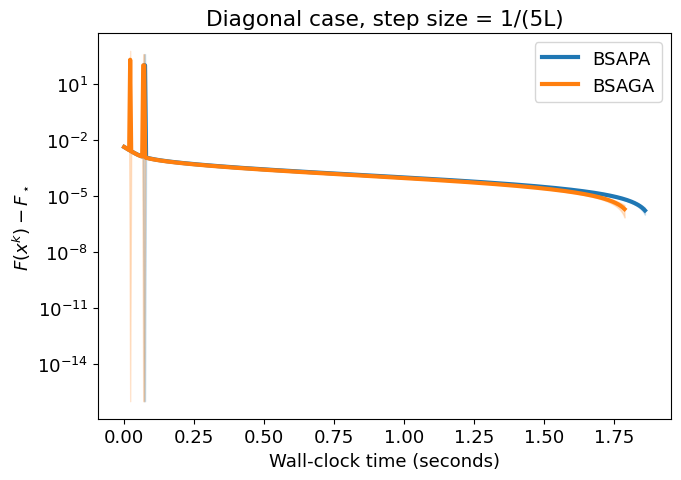

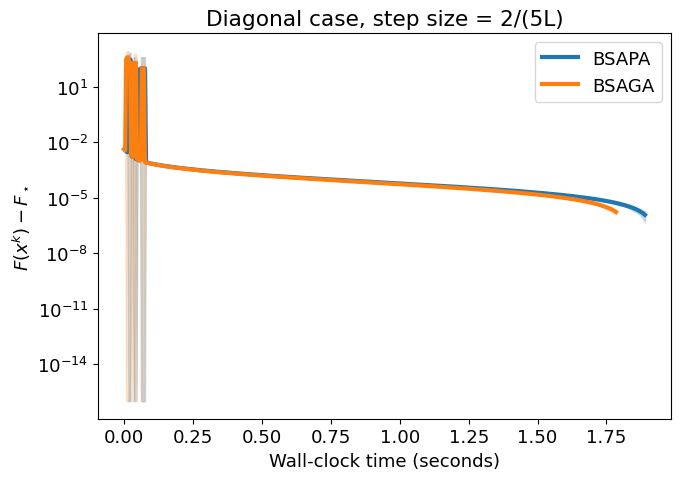

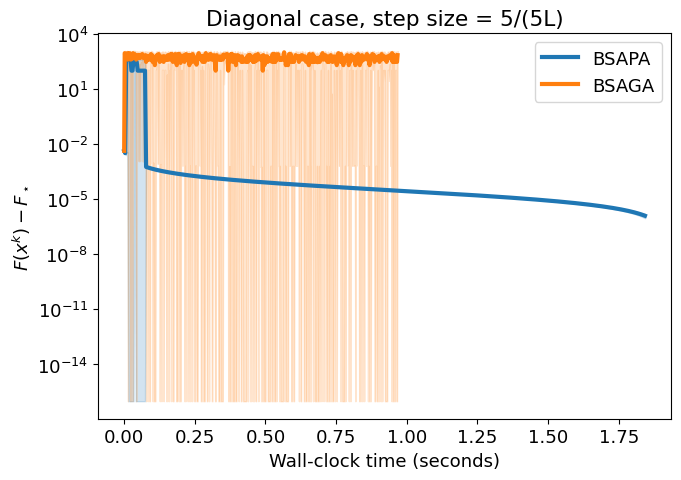

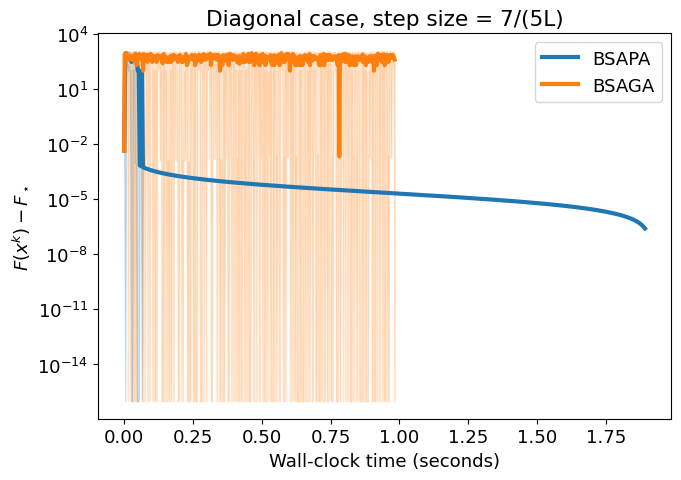

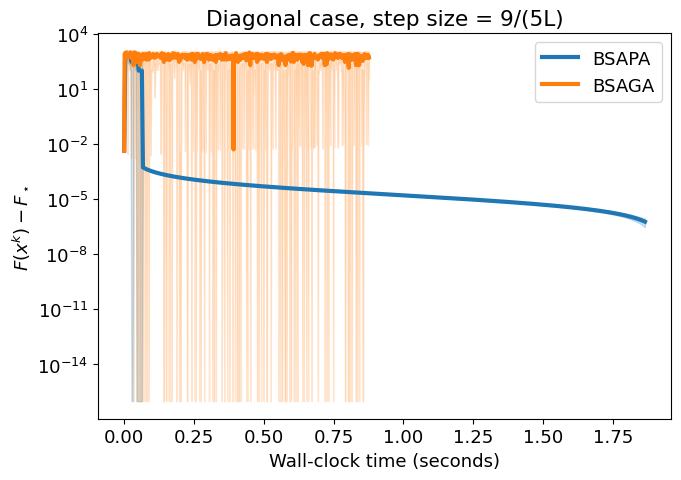

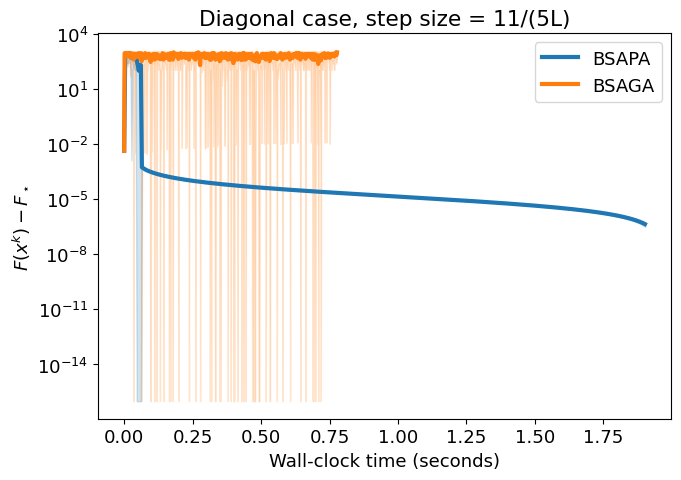

In [13]:
# Compare BSAPA vs BSAGA for several step sizes.
step_factors = [1., 2., 5., 7., 9., 11.]


all_results = {}

for factor in step_factors:
    step_size = factor / (5.0 * L)

    results = {
        "BSAPA": run_experiment_wall_clock(
            A,
            b,
            x0,
            step_size=step_size,
            max_iter=max_iter,
            method=sapa_bregman_diagonal,
            n_runs=n_runs,
            seed=seed,
            use_vr=True,
            diminishing_step=False,
        ),
        "BSAGA": run_experiment_wall_clock(
            A,
            b,
            x0,
            step_size=step_size,
            max_iter=max_iter,
            method=saga_bregman_diagonal,
            n_runs=n_runs,
            seed=seed,
            use_vr=True,
            diminishing_step=False,
        ),

    }

    all_results[factor] = results

    plot_trajectories_wall_clock(
        results,
        shade=shade,
        title=fr"Diagonal case, step size = {int(factor)}/(5L)",
    )
    plt.savefig("Plots/poisson_{}_diag_wall_clock_all_bsapa_vs_bsaga.png".format(factor), bbox_inches="tight", dpi=200)
    plt.show()
    plt.close()

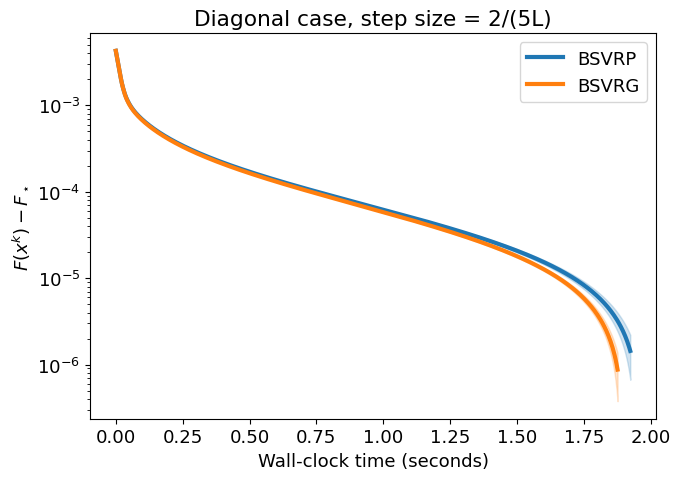

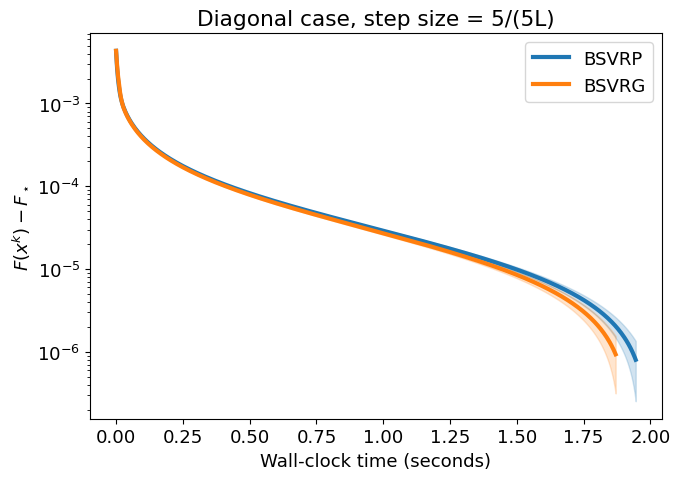

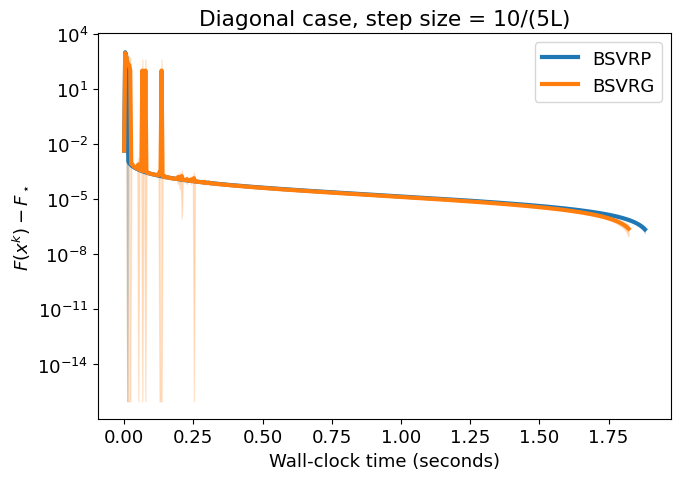

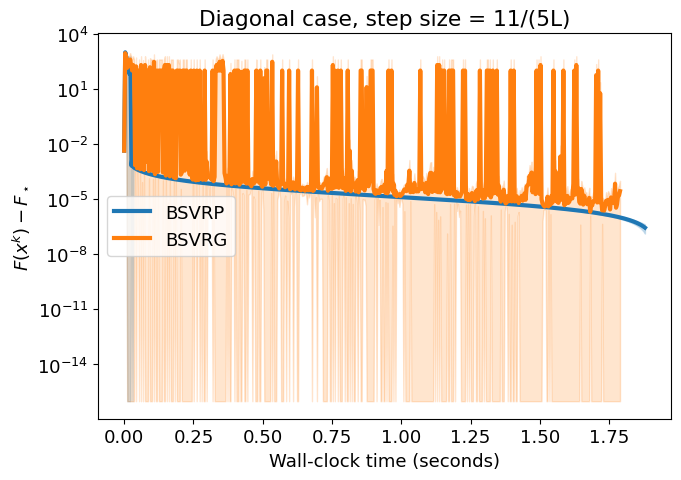

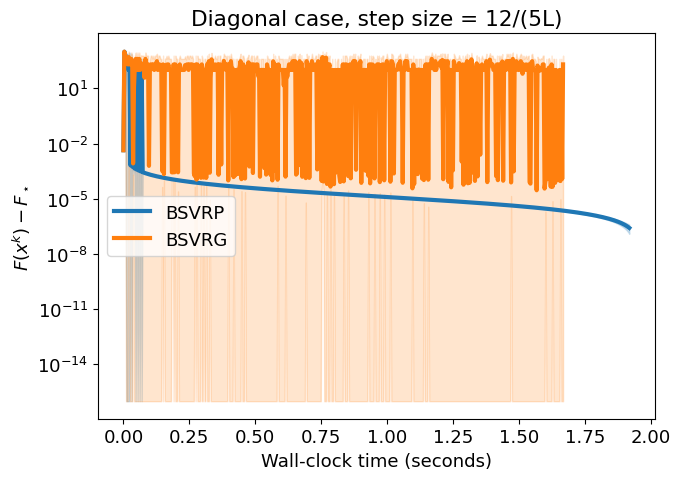

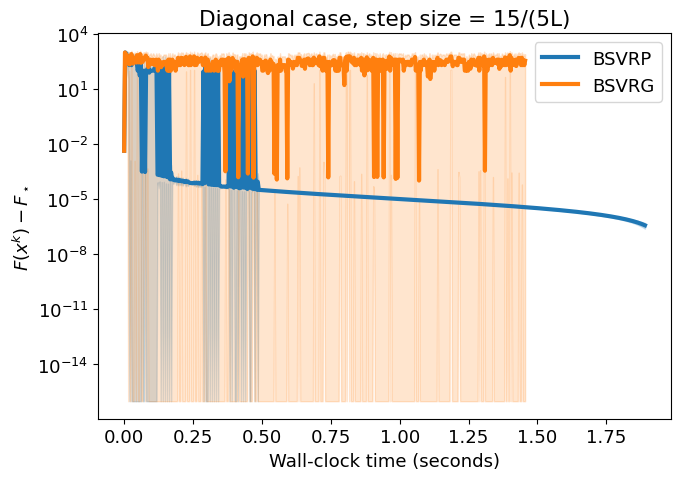

In [14]:

step_factors = [2.0, 5.0, 10., 11., 12., 15.]


all_results = {}

for factor in step_factors:
    step_size = factor / (5.0 * L)

    results = {

        "BSVRP": run_experiment_wall_clock(
            A,
            b,
            x0,
            step_size=step_size,
            max_iter=max_iter,
            method=bregman_svrp_diagonal,
            n_runs=n_runs,
            seed=seed,
            use_vr=True,
            diminishing_step=False,
        ),
        "BSVRG": run_experiment_wall_clock(
            A,
            b,
            x0,
            step_size=step_size,
            max_iter=max_iter,
            method=bregman_svrg_diagonal,
            n_runs=n_runs,
            seed=seed,
            use_vr=True,
            diminishing_step=False,
        ),

    }

    all_results[factor] = results

    plot_trajectories_wall_clock(
        results,
        shade=shade,
        title=fr"Diagonal case, step size = {int(factor)}/(5L)",
    )
    plt.savefig("Plots/poisson_{}_diag_wall_clock_all_bsvrp_vs_bsvrg.png".format(factor), bbox_inches="tight", dpi=200)
    plt.show()
    plt.close()

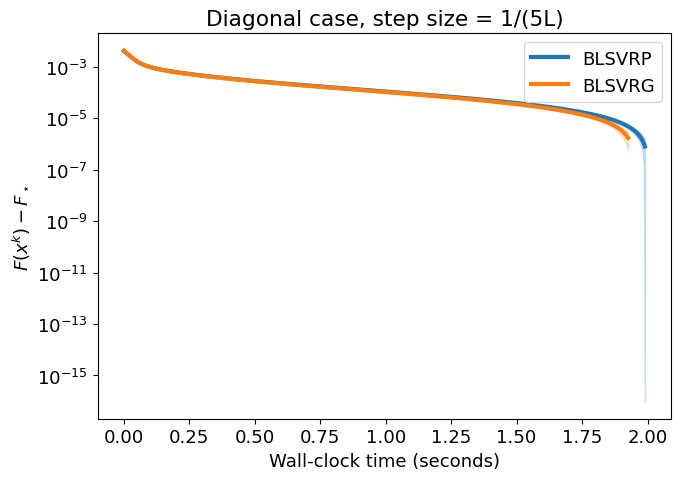

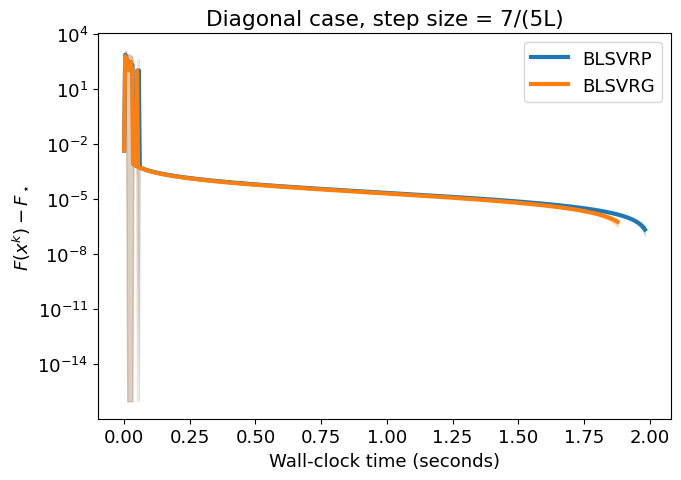

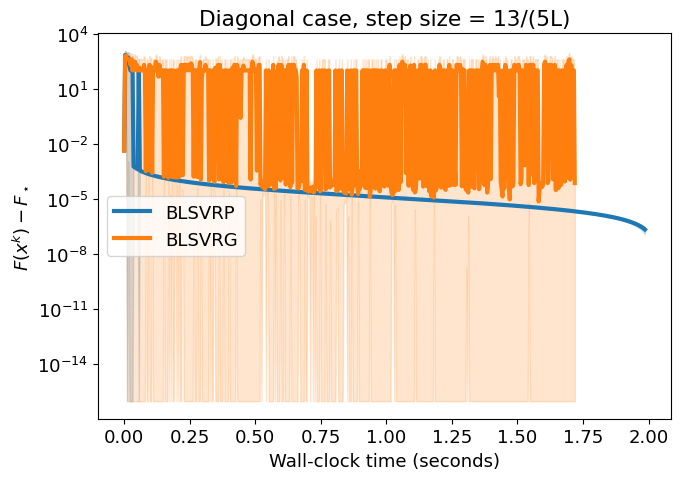

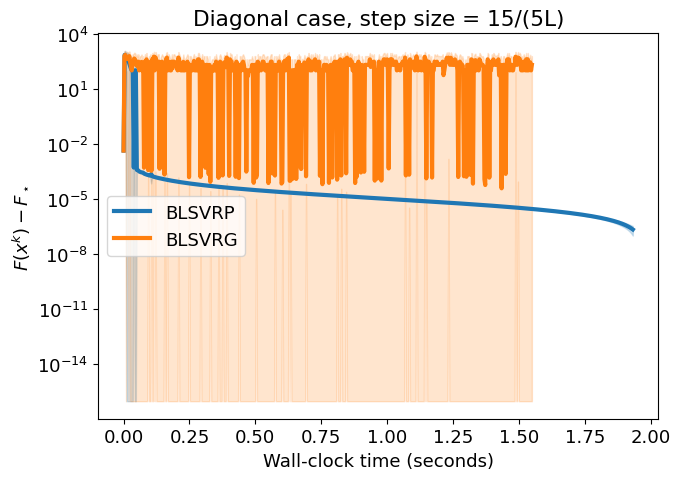

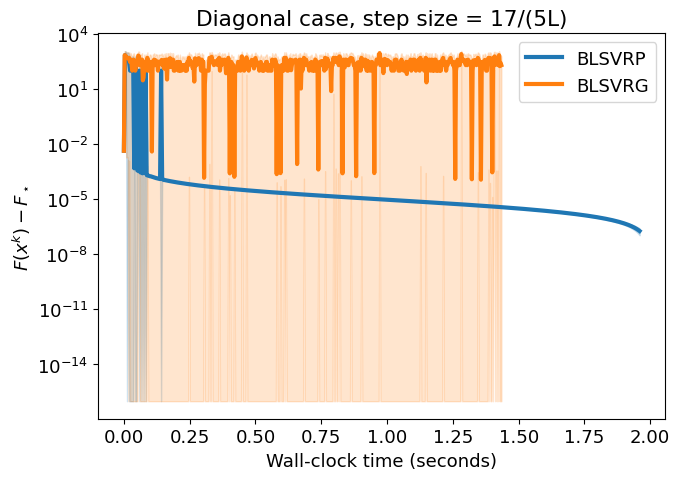

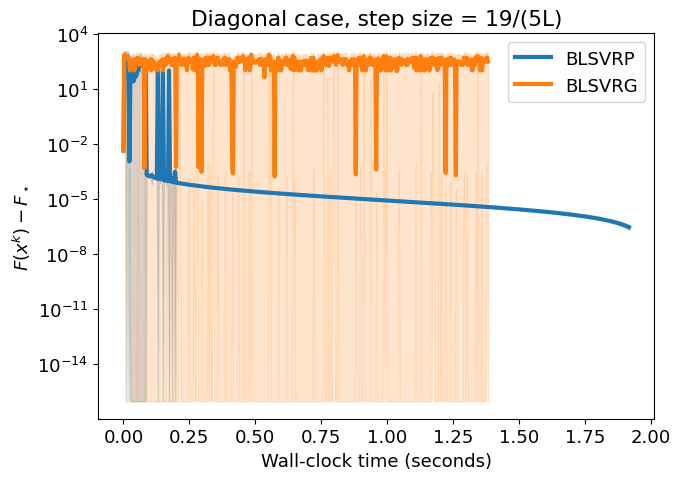

In [15]:
# Compare BLSVRP vs BLSVRG for several step sizes.
step_factors = [1.0, 7., 13., 15., 17., 19.]


all_results = {}

for factor in step_factors:
    step_size = factor / (5.0 * L)

    results = {

        "BLSVRP": run_experiment_wall_clock(
            A,
            b,
            x0,
            step_size=step_size,
            max_iter=max_iter,
            method=bregman_loopless_svrp_diagonal,
            n_runs=n_runs,
            seed=seed,
            use_vr=True,
            diminishing_step=False,
        ),
        "BLSVRG": run_experiment_wall_clock(
            A,
            b,
            x0,
            step_size=step_size,
            max_iter=max_iter,
            method=bregman_loopless_svrg_diagonal,
            n_runs=n_runs,
            seed=seed,
            use_vr=True,
            diminishing_step=False,
        ),
    }

    all_results[factor] = results

    plot_trajectories_wall_clock(
        results,
        shade=shade,
        title=fr"Diagonal case, step size = {int(factor)}/(5L)",
    )
    plt.savefig("Plots/poisson_{}_diag_wall_clock_all_blsvrp_vs_blsvrg.png".format(factor), bbox_inches="tight", dpi=200)
    plt.show()
    plt.close()